# Symulator tomografu komputerowego

### Skład grupy

- Paulina Serdeczna 160191
- Oliwia Tarent 160262

### Zastosowany model tomografu

W projekcie zostosowany został model stożkowy tomografu. Ruch emitera i detektorów został zamodelowany z użyciem przedstawionej poniżej funkcji kąta.

<br>

<img src="./notebook_img/model.png" height="400px"/>
<img src="./notebook_img/funkcja.png" height="400px" />

### Zastosowany język programowania oraz dodatkowe biblioteki

Do realizacji projektu użyty został język Python. Projekt powstał w postaci interaktywnego notebook'a.

Biblioteki użyte w projekcie:
1. **skimage** - wczytywanie obrazu wejściowego, algorytm Bresenhama, funkcje pomocnicze do tworzenia pliku DICOM, obliczanie błędu średniokwadratowego
2. **matplotlib** - wyświetlanie obrazów
3. **numpy** - wykonywanie obliczeń
4. **ipywidget** - możliwość zmiany parametrów programu w czasie rzeczywistym
5. **pydicom** - tworzenie pliku DICOM

In [16]:
from skimage import io, color, img_as_float
from skimage.draw import line_nd
import matplotlib.pyplot as plt
import numpy as np
import pydicom
from ipywidgets import interact, IntSlider
from pydicom.dataset import Dataset, FileDataset
from pydicom.dataset import Dataset, FileDataset
from pydicom.uid import CTImageStorage, ExplicitVRLittleEndian, generate_uid
from skimage import img_as_uint
from skimage.exposure import rescale_intensity
from skimage import img_as_uint
from skimage.exposure import rescale_intensity

from skimage.metrics import mean_squared_error

### Kod programu

#### Transformata Radona (tworzenie sinogramu)

In [17]:
def sample_line(img, x0, y0, x1, y1):
    h, w = img.shape

    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)

    values = []

    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            values.append(img[r, c])

    return np.sum(values)

In [18]:
def radon_transformation(img, alpha, n, phi, iterations=None):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    angles = np.deg2rad(np.arange(0, 360, alpha))

    sinogram = []

    if iterations is None:
        iterations = len(angles)

    iterations = min(iterations, len(angles))

    for iteration in range(iterations):
        a = angles[iteration]
        projections = []

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sample_line(img, xE, yE, xD, yD)
            projections.append(val)

        sinogram.append(projections)

    return np.array(sinogram)

#### Filtrowanie sinogramu

In [19]:
def filter(sinogram):
    filtered_sinogram = []
    kernel = []

    for k in range(-10, 11):
        if k == 0:
            kernel.append(1)
        elif k % 2 == 0:
            kernel.append(0)
        else:
            kernel.append((-4 / (np.pi**2)) / k**2)

    for i in range(len(sinogram)):
        filtered_sinogram.append(np.convolve(sinogram[i, :], kernel, mode='same'))

    return np.array(filtered_sinogram)

#### Odwrotna transformata Radona (rekonstrukcja obrazu)

In [20]:
def get_line(img, x0, y0, x1, y1):
    h, w = img.shape

    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)

    points = []

    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            points.append((c, r))

    return points

In [21]:
def inverse_radon_transformation(img, sinogram, alpha, n, phi, iterations=None):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    reconstructed_img = np.zeros((h, w))

    angles = np.deg2rad(np.arange(0, 360, alpha))

    if iterations is None:
        iterations = len(angles)

    iterations = min(iterations, len(angles))

    for iteration in range(iterations):
        a = angles[iteration]

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            line = get_line(img, xE, yE, xD, yD)

            val = sinogram[iteration, i]

            for x, y in line:
                if 0 <= x < w and 0 <= y < h:
                    reconstructed_img[y, x] += val

    img_min = np.min(reconstructed_img)
    img_max = np.max(reconstructed_img)

    reconstructed_img = (reconstructed_img - img_min) / (img_max - img_min)

    return reconstructed_img

#### Zapis pliku DICOM

In [22]:
def convert_image_to_uint16(img):
    return img_as_uint(rescale_intensity(img, out_range=(0.0, 1.0)))

def save_as_dicom(file_name, img, patient_data):
    img_converted = convert_image_to_uint16(img)

    meta = Dataset()
    meta.MediaStorageSOPClassUID = pydicom.uid.CTImageStorage
    meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
    meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian

    ds = FileDataset(None, {}, preamble=b"\0" * 128)
    ds.file_meta = meta

    ds.is_little_endian = True
    ds.is_implicit_VR = False

    ds.SOPClassUID = pydicom.uid.CTImageStorage
    ds.SOPInstanceUID = meta.MediaStorageSOPInstanceUID

    ds.PatientName = patient_data["PatientName"]
    ds.PatientID = patient_data["PatientID"]
    ds.ImageComments = patient_data["ImageComments"]

    ds.Modality = "CT"
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.FrameOfReferenceUID = pydicom.uid.generate_uid()

    ds.BitsStored = 16
    ds.BitsAllocated = 16
    ds.SamplesPerPixel = 1
    ds.HighBit = 15

    ds.ImagesInAcquisition = 1
    ds.InstanceNumber = 1

    ds.Rows, ds.Columns = img_converted.shape

    ds.ImageType = r"ORIGINAL\PRIMARY\AXIAL"

    ds.PhotometricInterpretation = "MONOCHROME2"
    ds.PixelRepresentation = 0

    pydicom.dataset.validate_file_meta(ds.file_meta, enforce_standard=True)

    ds.PixelData = img_converted.tobytes()

    ds.save_as(file_name, write_like_original=False)

#### Wyświetlanie wyników

In [23]:
def ct(filename, alpha, n, phi_deg, progress=100, useFilter=True):
    try:
        img = io.imread(f'img/{filename}')
        img = img_as_float(img)

        if len(img.shape) == 3:
            img = color.rgb2gray(img)

        phi_rad = np.deg2rad(phi_deg)

        total_iterations = len(np.arange(0, 360, alpha))
        current_iterations = int(total_iterations * (progress / 100))

        sinogram = radon_transformation(img, alpha, n, phi_rad, current_iterations)

        if useFilter:
            sinogram = filter(sinogram)

        global reconstructed_img
        reconstructed_img = inverse_radon_transformation(img, sinogram, alpha, n, phi_rad, current_iterations)

        if np.max(reconstructed_img) > 0:
            reconstructed_img = reconstructed_img / np.max(reconstructed_img)

        fig, axes = plt.subplots(
            1, 3,
            figsize=(20, 6),
            gridspec_kw={'width_ratios': [1, 1.3, 1]}
        )

        axes[0].imshow(img, cmap='gray')
        axes[0].set_title("Obraz wejściowy")
        axes[0].axis('off')

        axes[1].imshow(sinogram, cmap='gray')
        axes[1].set_title("Sinogram")

        axes[2].imshow(reconstructed_img, cmap='gray', aspect='equal')
        axes[2].set_title(f"Zrekonstruowany obraz")
        axes[2].axis('off')

        dicom_filename = filename.split('.')[0]
        save_as_dicom(f'./dcm/{dicom_filename}.dcm', reconstructed_img, {'PatientName': 'Scout', 'PatientID': '45', 'ImageComments': 'test'})

        error = mean_squared_error(img, reconstructed_img)

        info_text = (
            f"Plik: {filename}\n"
            f"Krok (alpha): {alpha}\n"
            f"Detektory (n): {n}\n"
            f"Rozpiętość: {phi_deg}°\n"
            f"Filtr: {'Tak' if useFilter else 'Nie'}\n"
            f"MSE: {error:.6f}"
        )

        fig.suptitle(info_text,
                    fontsize=10,
                    family='monospace',
                    y=-0.1,
                    va='bottom',
                    ha='center',
                    bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout(rect=[0, 0.15, 1, 1])

        plt.show()
    except FileNotFoundError:
        print('Podaj poprawną nazwę pliku!')

### Opis głównych funkcji programu

**a. Pozyskiwanie odczytów dla poszczególnych detektorów**

Funkcja `radon_transformation` zarządza całym procesem skanowania. Na początku, obliczany jest promień okręgu $r$, na którym rozmieszczane będą detektory. Dla każdego kąta obrotu obliczane jest położenie emitera $(xE, yE)$ oraz rozmieszczenie $n$ detektorów rozstawionych na okręgu o rozpiętości $\phi$. Następnie, funkcja sumuje jasność pikseli na linii pomiędzy emiterem a detektorem, przy pomocy funkcji `sample_line`. Wyniki z wszystkich detektorów łączone są w strukturę nazywaną sinogramem, której celem jest zaprezentowanie dystrybucji jasności w obrazie.

```py
    for iteration in range(iterations):
        a = angles[iteration]
        projections = []

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sample_line(img, xE, yE, xD, yD)
            projections.append(val)

        sinogram.append(projections)
```

<br>

**b. Filtrowanie sinogramu, zastosowany rozmiar maski**

W celu wyeliminowania rozmycia w obrazie wynikowym, zastosowałyśmy filtrowanie. Filtrowanie sinogramu polega na utworzeniu i wykorzytaniu filtra usuwającego rozmycie, tzw. `kernela`, który tworzony jest dynamicznie.

```py
    for k in range(-10, 11):
        if k == 0:
            kernel.append(1)
        elif k % 2 == 0:
            kernel.append(0)
        else:
            kernel.append((-4 / (np.pi**2)) / k**2)
```

Wielkość maski wynosi **21 elementów**. Po wyznaczeniu kernela, jest on nakładany na każdy wiersz sinogramu, przy użyciu funkcji `convolve` biblioteki numpy:

```py
    for i in range(len(sinogram)):
        filtered_sinogram.append(np.convolve(sinogram[i, :], kernel, mode='same'))
```

<br>

**c. Ustalanie jasności poszczególnych punktów obrazu wynikowego oraz jego przetwarzanie końcowe (np. uśrednianie, normalizacja)**

Funkcja `inverse_radon_transformation` odpowiada za rekontrukcję obrazu przy pomocy sinogramu. Dla każdego kąta i każdego detektora wyznaczana jest linia łącząca emiter z detektorem, przy użyciu funkcji pomocniczej `get_line`. Następnie wartość z sinogramu odpowiadająca temu promieniowi jest dodawana do każdego piksela obrazu wyjściowego (pierwotnie całego czarnego) leżącego na tej linii. Po zakończeniu wszystkich iteracji konieczna jest normalizacja wyniku, aby móc poprawnie wyświetlić obraz wyjsciowy.

```py
    img_min = np.min(reconstructed_img)
    img_max = np.max(reconstructed_img)

    reconstructed_img = (reconstructed_img - img_min) / (img_max - img_min)
```

<br>

**d. Wyznaczanie wartości miary RMSE na podstawie obrazu źródłowego oraz wynikowego**

Do wyznaczenia wartości miary RMSE użyta została gotowa funkcja `mean_squared_error` z biblioteki `skimage`.

```py
    error = mean_squared_error(img, reconstructed_img)
```

<br>

**e. Odczyt i zapis plików DICOM**

Obsługa generowania plików DICOM opiera się na funkcjach z biblioteki `pydicom` oraz narzędziach przetwarzania obrazów biblioteki `skimage`. Na początku następuje normalizacja obrazu wyjściowego do formatu bez znaku przy użyciu funkcji pomocniczej `convert_image_to_uint16`.

```py
    def convert_image_to_uint16(img):
        return img_as_uint(rescale_intensity(img, out_range=(0.0, 1.0)))
```

Przed utworzeniem pliku DICOM tworzony jest nagłówek klasy obiektu, który następnie dołączany jest do tego pliku. Do informacji pliku dołączane są dane pacjenta oraz parametry techniczne badania, takie jak imię, ID pacjenta, komentarz, typ badania.

```py
    ds.PatientName = patient_data["PatientName"]
    ds.PatientID = patient_data["PatientID"]
    ds.ImageComments = patient_data["ImageComments"]
    ds.Modality = "CT"
```

Pliki DICOM są identyfikowane przez unikalne w skali światowej identyfikatory, które generowane są z użyciem wbudowanej w bibliotekę `pydicom` funkcji `generate_uid()`.

```py
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.FrameOfReferenceUID = pydicom.uid.generate_uid()

```

Inicjalizowane są również parametry formatu obrazu w pliku DICOM, wskazując na liczba zapisanych bitów na piksel, liczba próbek na piksel oraz wskazanie najstarszego bitu.

```py
    ds.BitsStored = 16
    ds.BitsAllocated = 16
    ds.SamplesPerPixel = 1
    ds.HighBit = 15
```

Funkcja kończy się utworzeniem pliku DICOM o rozszerzeniu `.dcm` i o nazwie wskazanej przez użytkownika.

```py
    ds.save_as(file_name, write_like_original=False)
```

### Przykład działania programu



In [24]:
interact(
    ct,
    filename='Shepp_logan.jpg',
    alpha=IntSlider(min=1, max=10, step=1, value=4, description='Krok (deg):'),
    n=IntSlider(min=90, max=360, step=10, value=180, description='Detektory:'),
    phi_deg=IntSlider(min=45, max=270, step=15, value=90, description='Rozpiętość:'),
    progress=IntSlider(min=2, max=100, step=2, value=100, description='Postęp %:'),
    useFilter=True
)

interactive(children=(Text(value='Shepp_logan.jpg', description='filename'), IntSlider(value=4, description='K…

<function __main__.ct(filename, alpha, n, phi_deg, progress=100, useFilter=True)>

Podaj poprawną nazwę pliku!


Podaj poprawną nazwę pliku!


Podaj poprawną nazwę pliku!


KeyboardInterrupt: 

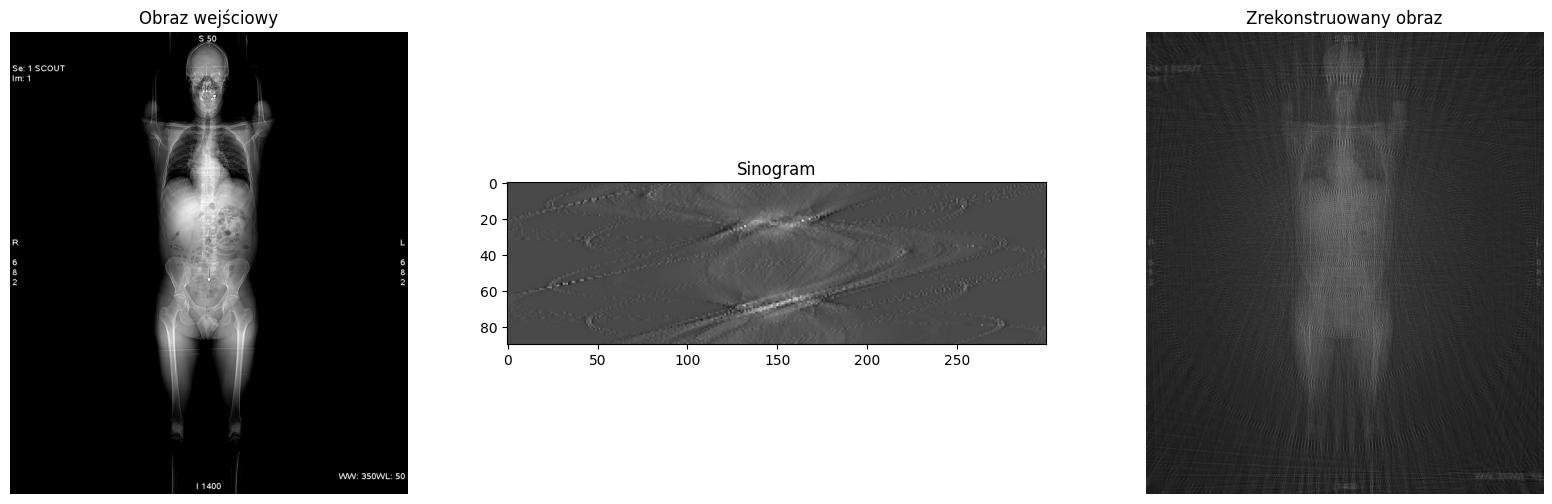

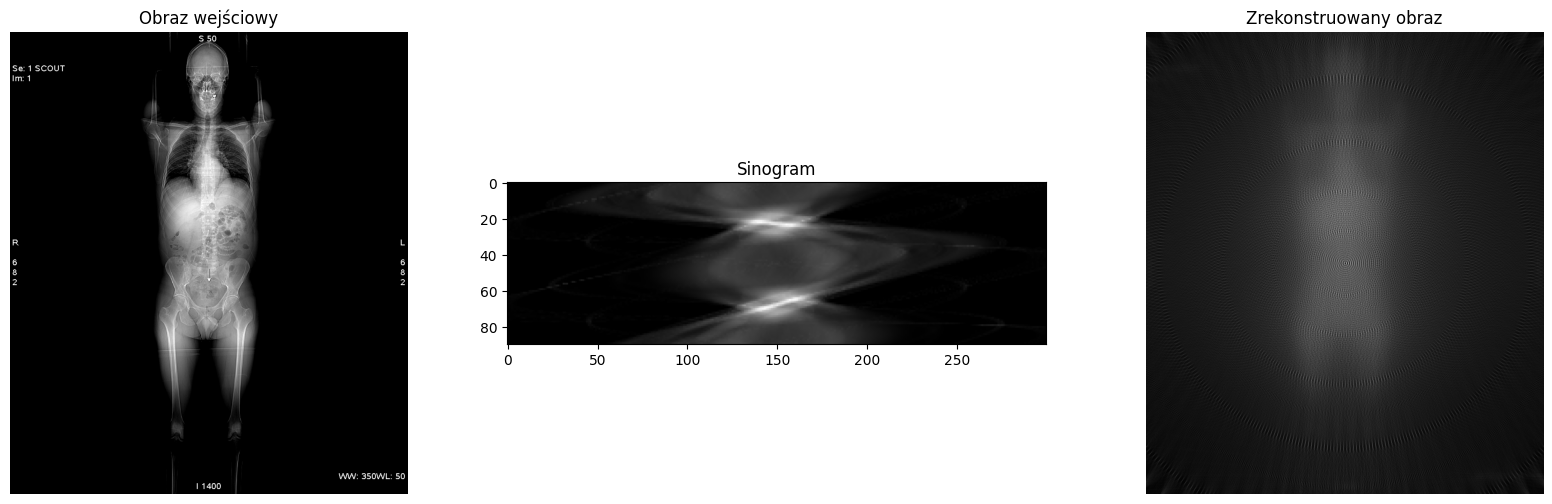

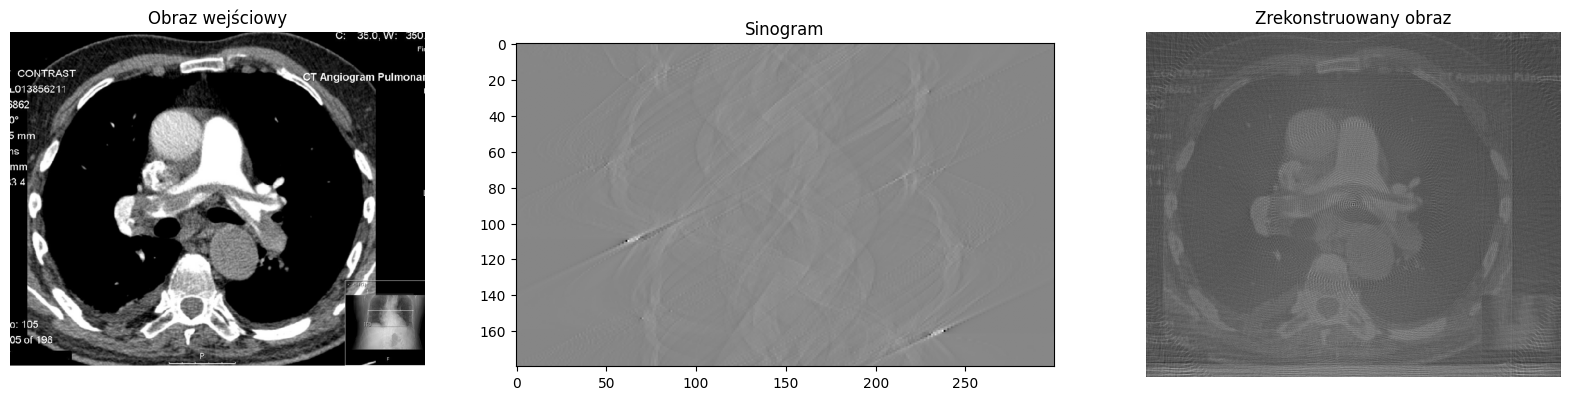

In [25]:
img = 'CT_ScoutView.jpg'
ct(img, 4, 300, 225, 100, True)
ct(img, 4, 300, 225, 100, False)

img = 'SADDLE_PE.JPG'
ct(img, 2, 300, 270, 100, True)
ct(img, 2, 300, 270, 100, False)

### Eksperyment



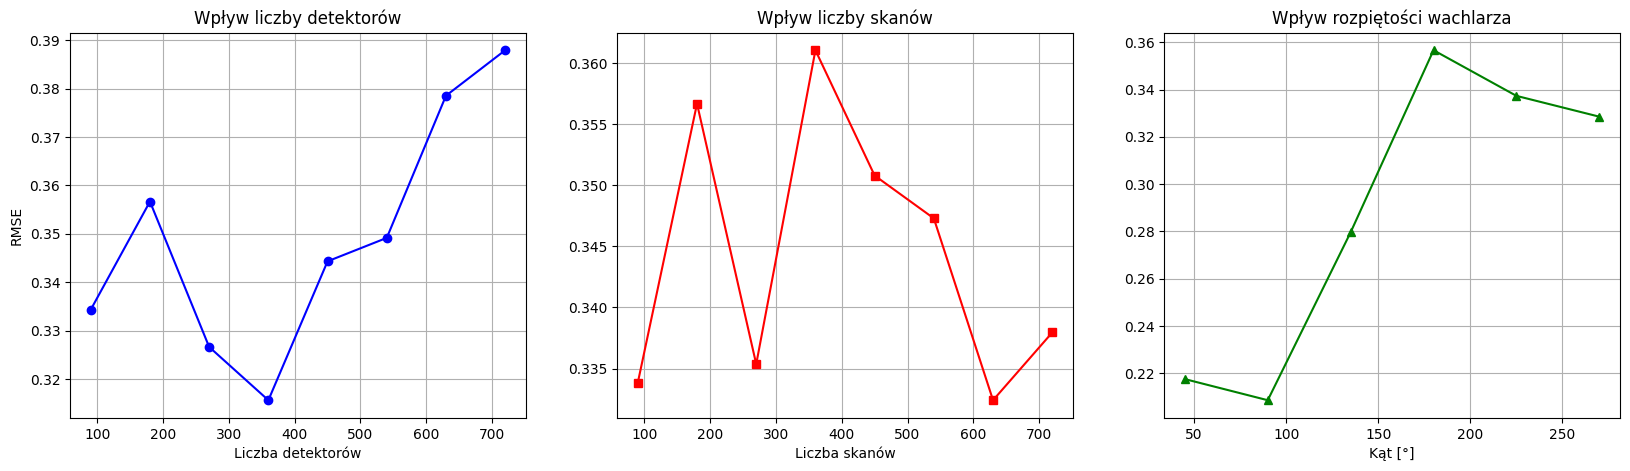

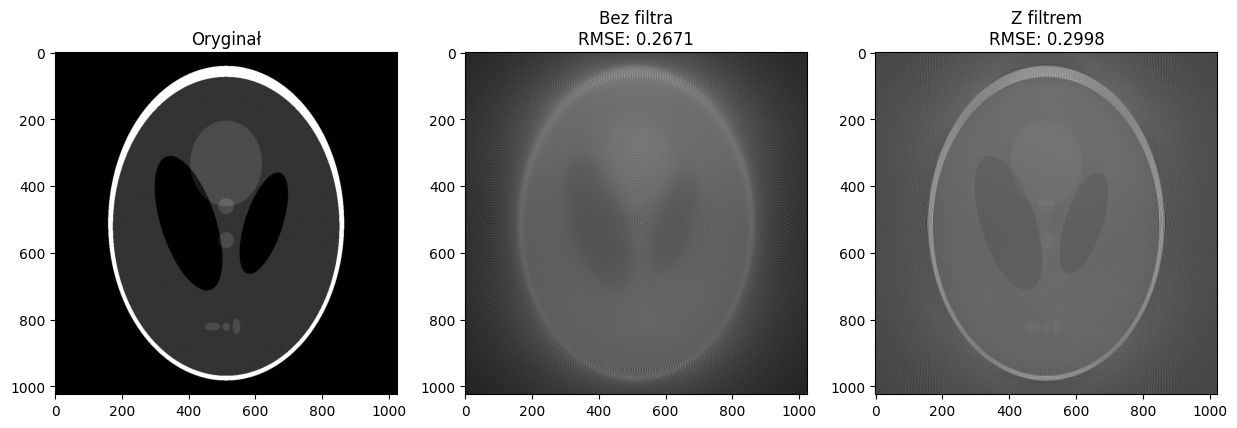

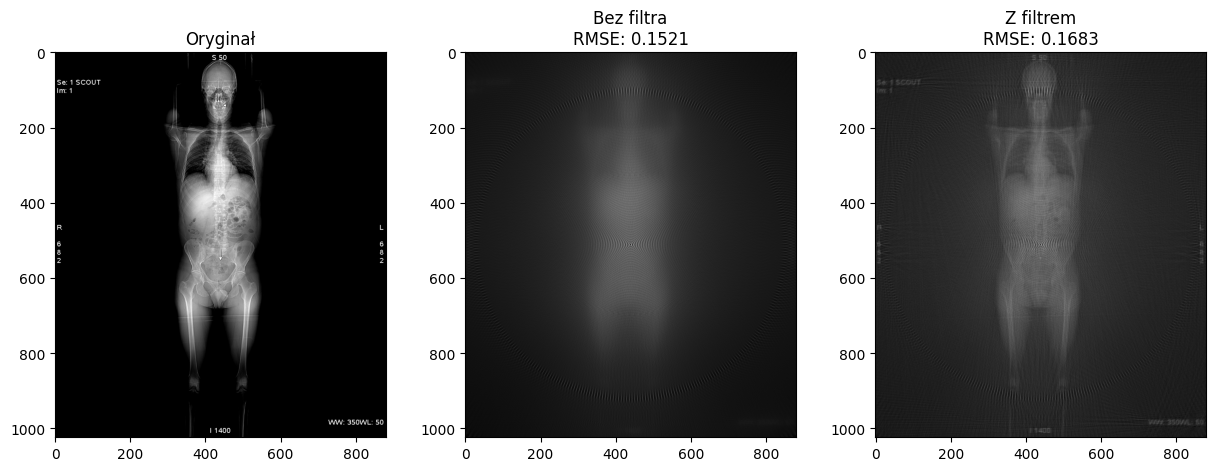

In [29]:
def calculate_rmse(img1, img2):
    img1_norm = img1.copy()
    img1_min = np.min(img1)
    img1_max = np.max(img1)
    if img1_max > img1_min:
        img1_norm = (img1 - img1_min) / (img1_max - img1_min)

    img2_norm = img2.copy()
    img2_min = np.min(img2)
    img2_max = np.max(img2)
    if img2_max > img2_min:
        img2_norm = (img2 - img2_min) / (img2_max - img2_min)

    return np.sqrt(mean_squared_error(img1_norm, img2_norm))

def run_experiment(img):
    base_n = 180
    base_scans = 180
    base_phi_deg = 180
    base_phi_rad = np.deg2rad(base_phi_deg)
    base_alpha = 360 / base_scans

    n_values = list(range(90, 721, 90))
    scans_values = list(range(90, 721, 90))
    phi_values = list(range(45, 271, 45))
    rmse_n, rmse_scans, rmse_phi = [], [], []

    for n in n_values:
        sino = filter(radon_transformation(img, base_alpha, n, base_phi_rad))
        recon = inverse_radon_transformation(img, sino, base_alpha, n, base_phi_rad)
        rmse_n.append(calculate_rmse(img, recon))

    for scans in scans_values:
        alpha = 360 / scans
        sino = filter(radon_transformation(img, alpha, base_n, base_phi_rad))
        recon = inverse_radon_transformation(img, sino, alpha, base_n, base_phi_rad)
        rmse_scans.append(calculate_rmse(img, recon))

    for phi_deg in phi_values:
        phi_rad = np.deg2rad(phi_deg)
        sino = filter(radon_transformation(img, base_alpha, base_n, phi_rad))
        recon = inverse_radon_transformation(img, sino, base_alpha, base_n, phi_rad)
        rmse_phi.append(calculate_rmse(img, recon))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(n_values, rmse_n, marker='o', color='b', label='RMSE(n)')
    axes[0].set_title('Wpływ liczby detektorów')
    axes[0].set_xlabel('Liczba detektorów')
    axes[0].set_ylabel('RMSE')
    axes[0].grid(True)

    axes[1].plot(scans_values, rmse_scans, marker='s', color='r', label='RMSE(skany)')
    axes[1].set_title('Wpływ liczby skanów')
    axes[1].set_xlabel('Liczba skanów')
    axes[1].grid(True)

    axes[2].plot(phi_values, rmse_phi, marker='^', color='g', label='RMSE(phi)')
    axes[2].set_title('Wpływ rozpiętości wachlarza')
    axes[2].set_xlabel('Kąt [°]')
    axes[2].grid(True)

    plt.show()

def filter_on_images(img1, img2):
    test_n = 360
    test_scans = 360
    test_phi_rad = np.deg2rad(270)
    test_alpha = 360 / test_scans

    for img_test in [img1, img2]:
        sino = radon_transformation(img_test, test_alpha, test_n, test_phi_rad)

        recon_no = inverse_radon_transformation(img_test, sino, test_alpha, test_n, test_phi_rad)
        rmse_no = calculate_rmse(img_test, recon_no)

        sino_f = filter(sino)
        recon_f = inverse_radon_transformation(img_test, sino_f, test_alpha, test_n, test_phi_rad)
        rmse_f = calculate_rmse(img_test, recon_f)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img_test, cmap='gray')
        axes[0].set_title("Oryginał")

        axes[1].imshow(recon_no, cmap='gray')
        axes[1].set_title(f"Bez filtra\nRMSE: {rmse_no:.4f}")

        axes[2].imshow(recon_f, cmap='gray')
        axes[2].set_title(f"Z filtrem\nRMSE: {rmse_f:.4f}")

        plt.show()


img = io.imread("img/Shepp_logan.jpg")
img2 = io.imread("img/CT_ScoutView.jpg")

if len(img.shape) == 3:
    img = color.rgb2gray(img)

if len(img2.shape) == 3:
    img2 = color.rgb2gray(img2)

run_experiment(img)
filter_on_images(img, img2)

### Wnioski



### 1. Wpływ poszczególnych parametrów na jakość obrazu wynikowego:

**a. liczba detektorów**

Jakość obrazu poprawia się aż do 360 detektorów. Dalsze zwiększanie liczby detektorów skutkuje wzrostem błędu. Wynika to z efektu oversamplingu - zwiększanie liczby detektorów ponad optymalną granicę sprawia, że rzuty promieni są rozłożone znacznie gęściej niż piksele obrazu źródłowego. Odwrotna Transformata Radona polega wtedy na głębokiej interpolacji, ponieważ filtrowanie wzmacnia wysokie częstotliwości. W efekcie dochodzi do wyostrzenia szumu.

**b. liczba skanów**

Jakość obrazu naprzemiennie spada i wzrasta, co może być efektem aliasingu. Najmniejszy błąd osiągnięto dla konkretnej liczby skanów (90, 270, 630). Przy tych wartościach rozdzielczość kątowa pozwala na najdokładniejsze odwzorowanie fantomu. Inne wartości generują większe błędy interpolacji na krawędziach, prowadząc do większego błędu.

**c. rozpiętość wachlarza**

Najmniejszy błąd osiągnięto dla wartości 90°. Zwiększanie rozpiętości pogarsza jakość obrazu wynikowego. Wynika to z dużej gęstości detektorów na stopień (2) oraz wystarczające pokrycie fantomu. Przy wyższych wartościach częśc promieni "omija" obiekt i rejestruje czarne tło wokół skanu, prowadząc do gorszych rezultatów.

<br>

### 2. Wpływ filtrowania na jakość obrazu

**a. Shepp-Logan**

Obraz niefiltrowany jest bardzo niewyraźny - trudno rozróżnić krawędzie, obiekt jest zamglony. Mimo to widoczny jest ogólny zarys oryginału oraz większych struktur.

Po zastosowaniu filtrowania rozmycie znika. Uwidczaniają się krawędzie i struktury wewnętrzne. Nieznaczny wzrost błędu może wynikać z nieuniknionego rozjaśnienia tła podczas filtrowania.

**b. CT Scout View**

Tutaj także obraz niefiltrowany jest niewyraźny. Efekt jest praktycznie bezużyteczny - detale nie są widoczne, a jedynie ogólny zarys fantomu.

Po filtrowaniu efekt jest zdecydowanie lepszy. Widoczne są detale anotomiczne oraz zróżnicowanie tkanek. Błąd ponownie jest nieznacznie większy, co jest spowodowane rozjaśnieniem tła poprzez filtrowanie.